# 03b — Shot-Type Classification (Supervised Contrastive)

Train the ST-GCN encoder on **ShuttleSet** skeletons for **shot-type classification** using
supervised contrastive learning (SupCon), with an optional cross-entropy (CE) classification head.

- **Labels:** 17 shot types from `SHOT_TYPES` (side-agnostic)
- **Loss ablation:** `LOSS_MODE` = `'supcon'` | `'ce'` | `'supcon_ce'` (joint)
- **Splits:** train / held-out from `shuttleset_split.json`

Saved checkpoint: `shot_type_{LOSS_MODE}_{layer}.pt`

In [9]:
import os, sys, zipfile
from pathlib import Path

# ── Colab detection ───────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    ZIP_PATH     = DRIVE_ROOT / 'baddiev2_colab.zip'

    if not (PROJECT_PATH / 'src').exists():
        print('Extracting project files...')
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(PROJECT_PATH)
        print(f'Extracted to {PROJECT_PATH}')
    else:
        print('Project already extracted.')

    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)

    import src.config as _cfg
    _cfg.MODELS_DIR            = DRIVE_ROOT / 'models'
    _cfg.RESULTS_DIR           = DRIVE_ROOT / 'results'
    _cfg.SS_SKELETONS_GDINO    = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.FB_SKELETONS_GDINO_V2 = DRIVE_ROOT / 'datasets_preprocessing' / 'finebadminton_skeletons_gdino_v2'
    _cfg.FB_ANNOTATIONS        = (
        DRIVE_ROOT / 'datasets' / 'FineBadminton-dataset' / 'dataset' /
        'transformed_combined_rounds_output_en_evals_translated.json'
    )
    _cfg.SS_CSV_ROOT   = DRIVE_ROOT / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV  = _cfg.SS_CSV_ROOT / 'match.csv'
    _cfg.SS_SPLIT_JSON = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'

    _cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    _cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    print(f'Drive root   : {DRIVE_ROOT}')
    print(f'Models dir   : {_cfg.MODELS_DIR}')
    print(f'SS skeletons : {_cfg.SS_SKELETONS_GDINO}')
    print(f'SS CSV root  : {_cfg.SS_CSV_ROOT}')
    print(f'SS CSV exists: {_cfg.SS_CSV_ROOT.exists()}')
else:
    sys.path.insert(0, os.path.abspath('..'))
    DRIVE_ROOT = Path('..')
    print('Local run — using paths from config.py')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project already extracted.
Drive root   : /content/drive/MyDrive/Baddiev2
Models dir   : /content/drive/MyDrive/Baddiev2/models
SS skeletons : /content/drive/MyDrive/Baddiev2/datasets_preprocessing/shuttleset_skeletons_gdino
SS CSV root  : /content/drive/MyDrive/Baddiev2/datasets/ShuttleSet/set
SS CSV exists: True


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

from src.config import *
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.simclr_loss import (
    SupConLoss, ProjectionHead, SkeletonAugmentor, AuxiliaryShotTypeHead
)

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Device: {device}")

## 1. Configuration

In [ ]:
cfg = get_config('shot_type_supcon')

# ── Feature layer toggle ──────────────────────────────────────────────────────
FEATURE_LAYER = 'L2'    # 'L0' | 'L1' | 'L2' | 'L3'

# ── Loss ablation toggle ─────────────────────────────────────────────────────
LOSS_MODE = 'supcon_ce'  # 'supcon' | 'ce' | 'supcon_ce'
CE_WEIGHT = 0.3          # weight for CE loss when LOSS_MODE='supcon_ce'
# ─────────────────────────────────────────────────────────────────────────────

# ── Overrides ────────────────────────────────────────────────────────────────
cfg.ssl.epochs = 100
cfg.data.shot_window = 32
cfg.stgcn.in_channels = FEATURE_DIMS[FEATURE_LAYER]
cfg.ssl.temperature = 0.2
cfg.ssl.jitter_std     = 0.02
cfg.ssl.mask_ratio     = 0.15
cfg.ssl.speed_range    = 0.20
cfg.ssl.rotation_range = 10

feature_dim = FEATURE_DIMS[FEATURE_LAYER]
cfg.stgcn.in_channels = feature_dim

print(f"Feature layer : {FEATURE_LAYER} ({feature_dim} features/node)")
print(f"Loss mode     : {LOSS_MODE}" + (f"  (CE weight={CE_WEIGHT})" if LOSS_MODE == 'supcon_ce' else ''))
print(f"Labels        : {NUM_SHOT_TYPES} shot types (side-agnostic)")
print(f"\nEncoder: ST-GCN")
print(f"  in_channels  : {cfg.stgcn.in_channels}")
print(f"  num_nodes    : {cfg.stgcn.num_nodes}")
print(f"  embedding_dim: {cfg.stgcn.embedding_dim}")
print(f"\nTraining config:")
print(f"  temperature  : {cfg.ssl.temperature}")
print(f"  epochs       : {cfg.ssl.epochs}")
print(f"  batch_size   : {cfg.ssl.batch_size}")

## 2. Build Model Components

In [ ]:
# Build graph adjacency
graph_builder = GraphBuilder(
    use_inter_player=cfg.ablation.use_inter_player,
    single_player=cfg.ablation.single_player,
)
adjacency = graph_builder.build_adjacency().to(device)
print(f"Adjacency: {adjacency.shape}")

# Build encoder
encoder = STGCN(
    in_channels=cfg.stgcn.in_channels,
    num_nodes=cfg.stgcn.num_nodes,
    adjacency=adjacency,
    num_layers=cfg.stgcn.num_layers,
    base_channels=cfg.stgcn.base_channels,
    embedding_dim=cfg.stgcn.embedding_dim,
    temporal_kernel=cfg.stgcn.temporal_kernel,
    dropout=cfg.stgcn.dropout,
).to(device)

# Projection head (for SupCon)
projector = ProjectionHead(
    embedding_dim=cfg.stgcn.embedding_dim,
    hidden_dim=cfg.ssl.projection_hidden,
    projection_dim=cfg.ssl.projection_dim,
).to(device)

# SupCon loss
contrastive_loss = SupConLoss(temperature=cfg.ssl.temperature)

# CE classification head — num_classes set after data loading (composite classes)
# Placeholder; will be initialized in the data cell once we know n_composite_classes
ce_head = None
ce_loss_fn = nn.CrossEntropyLoss()

augmentor = SkeletonAugmentor(
    jitter_std=cfg.ssl.jitter_std,
    mask_ratio=cfg.ssl.mask_ratio,
    speed_range=cfg.ssl.speed_range,
    rotation_range=cfg.ssl.rotation_range,
)

print(f"Loss mode: {LOSS_MODE}")
if LOSS_MODE in ('supcon', 'supcon_ce'):
    print(f"  SupConLoss (temperature={cfg.ssl.temperature})")
if LOSS_MODE in ('ce', 'supcon_ce'):
    print(f"  CrossEntropyLoss" + (f" (weight={CE_WEIGHT})" if LOSS_MODE == 'supcon_ce' else ''))

total_params = sum(p.numel() for p in encoder.parameters())
print(f"\nEncoder parameters: {total_params:,}")

## 3. Load Data

Uses splits from `shuttleset_split.json`:
- **Train:** 8 matches — used for training (early stopping on train loss)
- **Held out:** 2 matches — final evaluation only (never seen during training)

No separate val split — the split JSON says to use cross-validation on train.

In [5]:
## Inspect available skeletons before loading dataset
from src.config import SS_SKELETONS_GDINO

skel_root = SS_SKELETONS_GDINO
print(f"Skeleton dir: {skel_root}")
print(f"Exists: {skel_root.exists()}\n")

match_dirs = sorted([d for d in skel_root.iterdir() if d.is_dir()]) if skel_root.exists() else []
print(f"{'Match':<65} {'skeletons.npy':>14} {'frame_nums.npy':>15} {'Frames':>8}")
print("-" * 105)
total_frames = 0
for d in match_dirs:
    has_sk = (d / 'skeletons.npy').exists()
    has_fn = (d / 'frame_nums.npy').exists()
    n_frames = 0
    if has_fn:
        n_frames = len(np.load(str(d / 'frame_nums.npy')))
        total_frames += n_frames
    sk_str = f"{np.load(str(d / 'skeletons.npy')).shape}" if has_sk else "missing"
    fn_str = str(n_frames) if has_fn else "missing"
    print(f"  {d.name:<63} {sk_str:>14} {fn_str:>15} {n_frames:>8}")

print(f"\nTotal matches: {len(match_dirs)}  |  Total frames with skeletons: {total_frames:,}")

Skeleton dir: /content/drive/MyDrive/Baddiev2/datasets_preprocessing/shuttleset_skeletons_gdino
Exists: True

Match                                                              skeletons.npy  frame_nums.npy   Frames
---------------------------------------------------------------------------------------------------------
  1 empty                                                                missing         missing        0
  2 bad quality                                                          missing         missing        0
  Anders_ANTONSEN_Jonatan_CHRISTIE Indonesia_Masters_2020_QuarterFinals  (2, 1018, 34)            1018     1018
  Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_TOUR_FINALS_2020_Finals  (2, 6715, 34)            6715     6715
  Anthony_Sinisuka_GINTING_Anders_ANTONSEN_Indonesia_Masters_2020_Final  (2, 5347, 34)            5347     5347
  Anthony_Sinisuka_GINTING_Viktor_AXELSEN _Indonesia_Masters_2020_SemiFinals  (2, 3307, 34)            3307     3307
  Anthony_Sin

In [ ]:
from src.config import SS_SKELETONS_GDINO, SS_SPLIT_JSON, SHOT_TYPES, NUM_SHOT_TYPES

# ── Load splits from JSON ────────────────────────────────────────────────────
with open(SS_SPLIT_JSON) as f:
    splits = json.load(f)

TRAIN_MATCHES = set(splits['train'])
TEST_MATCHES  = set(splits['held_out'])    # held-out for final evaluation only

print(f"Train matches: {len(TRAIN_MATCHES)}")
print(f"Test matches:  {len(TEST_MATCHES)}")

# ── Helper: load dataset for a match set ─────────────────────────────────────
def load_split(match_set, name):
    ds = ShuttleSetDataset(
        skeleton_dir=SS_SKELETONS_GDINO,
        shot_window=cfg.data.shot_window,
        feature_layer=FEATURE_LAYER,
        load_shot_types=True,
        split=None,
    )
    # Filter to requested matches; shot_type_idx is already unified (0..16)
    ds.samples = [s for s in ds.samples if Path(s['skel_dir']).name in match_set]
    n_valid = sum(1 for s in ds.samples if s.get('shot_type_idx') is not None)
    n_no_type = len(ds.samples) - n_valid
    print(f"\n{name}: {len(ds)} samples | valid labels: {n_valid} | no type: {n_no_type}")
    return ds

train_dataset = load_split(TRAIN_MATCHES, 'Train')
test_dataset  = load_split(TEST_MATCHES, 'Test')

# ── Count classes ────────────────────────────────────────────────────────────
all_labels = set()
for ds in [train_dataset, test_dataset]:
    for s in ds.samples:
        if s.get('shot_type_idx') is not None:
            all_labels.add(s['shot_type_idx'])

n_classes = NUM_SHOT_TYPES  # 17
print(f"\nUnique labels seen: {len(all_labels)} / {n_classes}")
print(f"Label names: {SHOT_TYPES}")

# ── Initialize CE head ──────────────────────────────────────────────────────
ce_head = AuxiliaryShotTypeHead(cfg.stgcn.embedding_dim, n_classes).to(device)

# ── Build optimizer with all trainable components ────────────────────────────
params = list(encoder.parameters()) + list(projector.parameters()) + list(ce_head.parameters())
optimizer = optim.AdamW(params, lr=cfg.ssl.lr, weight_decay=cfg.ssl.weight_decay)
print(f"Total trainable: {sum(p.numel() for p in params):,}")

In [ ]:
def collate_fn(batch):
    """Collate (x, shot_type_label) tuples."""
    xs, labels = zip(*batch)
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.ssl.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
    collate_fn=collate_fn,
)

print(f"Train batches/epoch: {len(train_loader)}")

## 3b. Diagnostic Visualisations

Three diagnostic views before training:

1. **Positive-pair structure** — SupCon vs SimCLR side-by-side: which cells in the 2B x 2B similarity matrix act as "pull together"
2. **Training signal richness** — how many positives each anchor gets (SupCon >> SimCLR)
3. **Intra-class skeleton consistency** — do shots with the same shot type actually share similar posture?

> These cells are diagnostic only and do not affect training.

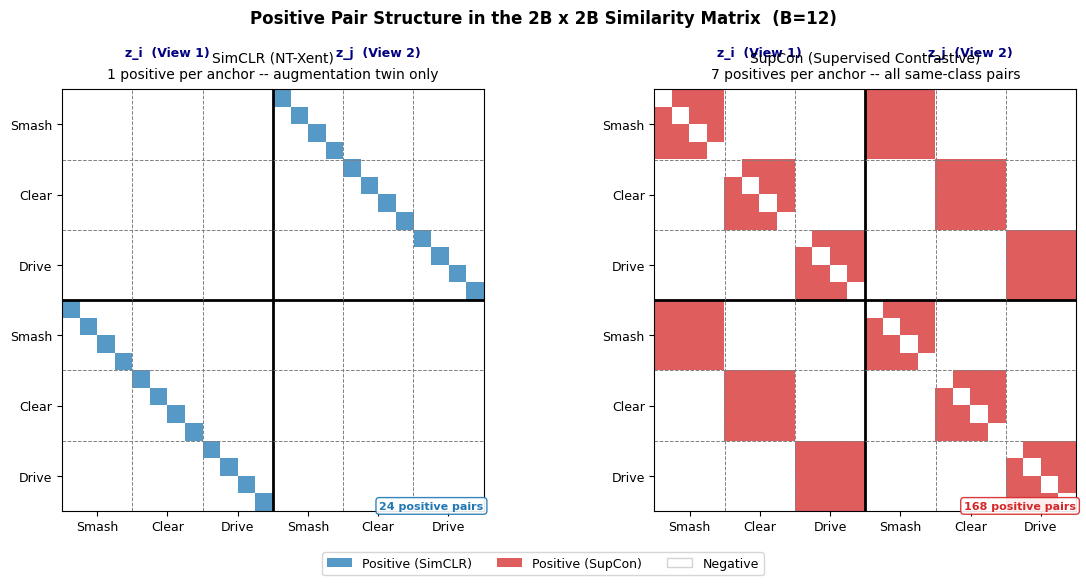

Saved: results/ssl_supcon_viz_positive_pair_structure.png


In [8]:
# ── Viz 1: Positive-pair structure — SimCLR vs SupCon ─────────────────────────
import matplotlib.patches as mpatches

_NPC, _CLS = 4, ['Smash', 'Clear', 'Drive']
_B   = _NPC * len(_CLS)
_lbl = np.concatenate([np.repeat(np.arange(len(_CLS)), _NPC)] * 2)

_sc = np.zeros((2*_B, 2*_B), bool)   # SimCLR: augmentation twins only
for _i in range(_B):
    _sc[_i, _i+_B] = _sc[_i+_B, _i] = True

_sp = (_lbl[:,None] == _lbl[None,:])  # SupCon: all same-class
np.fill_diagonal(_sp, False)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle(f'Positive Pair Structure in the 2B x 2B Similarity Matrix  (B={_B})',
             fontsize=12, fontweight='bold')

for ax, title, sub, mask, col in [
    (ax0, 'SimCLR (NT-Xent)', '1 positive per anchor -- augmentation twin only', _sc, '#1f77b4'),
    (ax1, 'SupCon (Supervised Contrastive)', f'{2*_NPC-1} positives per anchor -- all same-class pairs', _sp, '#d62728'),
]:
    bg = np.ones((2*_B, 2*_B, 4))
    bg[mask] = [int(col[1:3],16)/255, int(col[3:5],16)/255, int(col[5:7],16)/255, 0.75]
    ax.imshow(bg, interpolation='none')
    ax.axhline(_B-0.5, color='black', lw=2)
    ax.axvline(_B-0.5, color='black', lw=2)
    for c in range(1, len(_CLS)):
        for off in [0, _B]:
            p = off + c*_NPC - 0.5
            ax.axhline(p, color='gray', lw=0.7, ls='--')
            ax.axvline(p, color='gray', lw=0.7, ls='--')
    tks = [off + c*_NPC + _NPC/2 - 0.5 for off in [0,_B] for c in range(len(_CLS))]
    ax.set_xticks(tks); ax.set_xticklabels(_CLS*2, fontsize=9)
    ax.set_yticks(tks); ax.set_yticklabels(_CLS*2, fontsize=9)
    ax.text(_B/2-0.5,    -2.4, 'z_i  (View 1)', ha='center', fontsize=9, color='navy', fontweight='bold')
    ax.text(_B+_B/2-0.5, -2.4, 'z_j  (View 2)', ha='center', fontsize=9, color='navy', fontweight='bold')
    ax.set_title(f'{title}\n{sub}', fontsize=10, pad=8)
    ax.text(2*_B-0.5, 2*_B-0.5, f'{int(mask.sum())} positive pairs',
            ha='right', va='bottom', fontsize=8, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=col, alpha=0.9))

fig.legend(handles=[
    mpatches.Patch(fc='#1f77b4', alpha=0.75, label='Positive (SimCLR)'),
    mpatches.Patch(fc='#d62728', alpha=0.75, label='Positive (SupCon)'),
    mpatches.Patch(fc='white', ec='lightgray', label='Negative'),
], loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / 'ssl_supcon_viz_positive_pair_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/ssl_supcon_viz_positive_pair_structure.png")

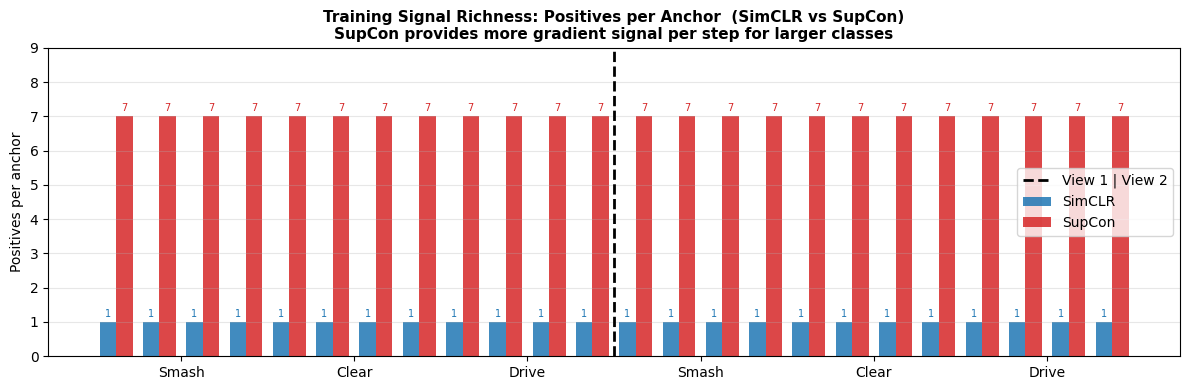

SimCLR: 1.0 positives per anchor (constant)
SupCon: 7.0 positives per anchor on average (7.0x more signal)
Saved: results/ssl_supcon_viz_training_signal.png


In [9]:
# ── Viz 2: Training signal richness ───────────────────────────────────────────
_sc_n = np.ones(2*_B, dtype=int)
_sp_n = np.array([int((_lbl == _lbl[i]).sum()) - 1 for i in range(2*_B)])

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(2*_B)
w = 0.38
ax.bar(x - w/2, _sc_n, w, color='#1f77b4', alpha=0.85, label='SimCLR')
ax.bar(x + w/2, _sp_n, w, color='#d62728', alpha=0.85, label='SupCon')
ax.axvline(_B - 0.5, color='black', lw=2, ls='--', label='View 1 | View 2')

tks = [off + c*_NPC + _NPC/2 - 0.5 for off in [0,_B] for c in range(len(_CLS))]
ax.set_xticks(tks); ax.set_xticklabels(_CLS*2, fontsize=10)
ax.set_ylabel('Positives per anchor'); ax.set_ylim(0, max(_sp_n) + 2)
ax.set_title(
    'Training Signal Richness: Positives per Anchor  (SimCLR vs SupCon)\n'
    'SupCon provides more gradient signal per step for larger classes',
    fontsize=11, fontweight='bold',
)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')

for i, (s, sp) in enumerate(zip(_sc_n, _sp_n)):
    ax.text(x[i]-w/2, s+0.1, str(s), ha='center', va='bottom', fontsize=7, color='#1f77b4')
    ax.text(x[i]+w/2, sp+0.1, str(sp), ha='center', va='bottom', fontsize=7, color='#d62728')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ssl_supcon_viz_training_signal.png', dpi=150, bbox_inches='tight')
plt.show()

_mean_sc = _sc_n.mean(); _mean_sp = _sp_n.mean()
print(f"SimCLR: {_mean_sc:.1f} positives per anchor (constant)")
print(f"SupCon: {_mean_sp:.1f} positives per anchor on average ({_mean_sp/_mean_sc:.1f}x more signal)")
print("Saved: results/ssl_supcon_viz_training_signal.png")

In [ ]:
# ── Viz 3: Intra-class skeleton consistency (shot types) ──────────────
# Same shot type => similar skeleton posture?
#
# NOTE: We read RAW pixel skeletons (pre-homography) for visualization so that
# body proportions look natural. The homography distorts body shape.

import matplotlib.gridspec as gridspec
from collections import defaultdict

_COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]

def _draw_skel(ax, xy17, color, alpha=1.0):
    for j1, j2 in _COCO_EDGES:
        x1,y1 = xy17[j1]; x2,y2 = xy17[j2]
        if max(abs(x1),abs(y1),abs(x2),abs(y2)) > 1e-4:
            ax.plot([x1,x2],[-y1,-y2],'-',color=color,lw=1.8,alpha=alpha)
    for j in range(17):
        if abs(xy17[j,0])+abs(xy17[j,1]) > 1e-4:
            ax.scatter(xy17[j,0],-xy17[j,1],s=18,c=color,alpha=alpha,zorder=5)

def _get_raw_pixel_skeleton(ds, idx):
    """Load raw pixel skeleton for sample idx, bypassing feature engineering.

    Returns (P0_xy, P1_xy) each shape (17, 2) at the middle frame,
    or (None, None) if unavailable.
    """
    info = ds.samples[idx]
    skel_dir = Path(info['skel_dir'])
    skel_path = skel_dir / 'skeletons.npy'
    if not skel_path.exists():
        return None, None

    # Load whole-match skeleton and find the hit frame
    whole_skel = np.load(str(skel_path))  # (2, T_full, 34)
    fn_arr = info['frame_nums_arr']
    diffs = np.abs(fn_arr - info['frame_num'])
    hit_idx = int(np.argmin(diffs))

    # Slice the same window the dataset uses
    half = ds.shot_window // 2
    T_full = whole_skel.shape[1]
    start = max(0, hit_idx - half)
    end = start + ds.shot_window
    if end > T_full:
        end = T_full
        start = max(0, end - ds.shot_window)
    segment = whole_skel[:, start:end, :]  # (2, T_win, 34)

    # Take middle frame
    mid = segment.shape[1] // 2
    xy = segment[:, mid, :].T  # (34, 2)
    return xy[:17], xy[17:]

# ── Collect samples per unified label from train set ─────────────────────────
N_COLS   = 10
MIN_SAMPLES = 3

by_label = defaultdict(list)
for i in range(len(train_dataset)):
    x, cl = train_dataset[i]
    if cl >= 0 and x.abs().sum() > 0:
        info = train_dataset.samples[i]
        meta = {
            'idx': i,
            'frame_num': info.get('frame_num', '?'),
            'hitter': info.get('hitter', '?'),
            'match': info.get('match_name', info.get('skel_dir', '?')),
        }
        m = str(meta['match'])
        if '/' in m:
            m = m.split('/')[-1]
        if len(m) > 30:
            m = m[:27] + '...'
        meta['match_short'] = m
        by_label[cl].append(meta)

available = [(cl, items) for cl, items in by_label.items() if len(items) >= MIN_SAMPLES]
available.sort(key=lambda kv: -len(kv[1]))
show_types = available[:10]

if not show_types:
    print("No labeled, non-zero samples found.")
else:
    N_ROWS = len(show_types)
    fig = plt.figure(figsize=(N_COLS * 2.2, N_ROWS * 2.8))
    fig.suptitle(
        'Intra-class Skeleton Consistency (Unified Shot Types)\n'
        'Each row = same shot type (side-agnostic)\n'
        'Blue = top-court player (P0) | Red = bottom-court player (P1)\n'
        'Raw pixel coords (pre-homography) for natural body proportions',
        fontsize=11, fontweight='bold', y=1.01,
    )

    gs = gridspec.GridSpec(N_ROWS, N_COLS, hspace=0.8, wspace=0.3)
    rng = np.random.RandomState(42)

    for row_i, (cl, items) in enumerate(show_types):
        chosen = rng.choice(len(items), size=min(N_COLS, len(items)), replace=False)
        shot_name = SHOT_TYPES[cl] if cl < len(SHOT_TYPES) else f'type_{cl}'
        label_disp = f"{shot_name}\n(n={len(items)})"

        for col_i, idx in enumerate(chosen):
            ax = fig.add_subplot(gs[row_i, col_i])
            meta = items[idx]
            p0, p1 = _get_raw_pixel_skeleton(train_dataset, meta['idx'])
            if p0 is None:
                ax.text(0.5, 0.5, 'no skel', ha='center', va='center',
                        fontsize=7, color='lightgray', transform=ax.transAxes)
                ax.axis('off')
                continue
            _draw_skel(ax, p0, color='royalblue')
            _draw_skel(ax, p1, color='tomato', alpha=0.4)
            ax.set_aspect('equal'); ax.axis('off')
            ax.set_title(
                f"f={meta['frame_num']}  h={meta['hitter']}\n{meta['match_short']}",
                fontsize=6, color='gray', pad=2,
            )
            if col_i == 0:
                ax.set_ylabel(label_disp, fontsize=8, rotation=0,
                              labelpad=65, va='center', ha='right')

        for col_i in range(len(chosen), N_COLS):
            ax = fig.add_subplot(gs[row_i, col_i])
            ax.axis('off')
            ax.text(0.5, 0.5, f'only\n{len(items)} samples', ha='center', va='center',
                    fontsize=7, color='lightgray', transform=ax.transAxes)

    fig.text(0.01, 0.5, 'Unified shot type', va='center',
             rotation='vertical', fontsize=10, color='navy', fontweight='bold')

    plt.savefig(RESULTS_DIR / 'shot_type_viz_intraclass_consistency.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nShot types shown ({N_ROWS}):")
    for cl, items in show_types:
        name = SHOT_TYPES[cl] if cl < len(SHOT_TYPES) else f'type_{cl}'
        print(f"  {name:<20} {len(items):>4} samples")
    print("\nSaved: results/shot_type_viz_intraclass_consistency.png")

## 4. Training Loop

In [ ]:
history = {'loss': [], 'epoch': []}

# Early stopping config
EARLY_STOP_PATIENCE = 10
EARLY_STOP_MIN_DELTA = 1e-4
best_loss = float('inf')
no_improve_count = 0
best_state = None

def compute_loss(x_batch, labels_batch):
    """Compute loss for a batch based on LOSS_MODE. Returns (loss, dict of components)."""
    x = x_batch.to(device)
    valid = labels_batch >= 0
    if not valid.any():
        return None, {}

    components = {}
    total_loss = torch.tensor(0.0, device=device)

    if LOSS_MODE in ('supcon', 'supcon_ce'):
        # Two augmented views for contrastive learning
        x_i = torch.stack([augmentor(xi) for xi in x])
        x_j = torch.stack([augmentor(xi) for xi in x])
        h_i = encoder(x_i)
        h_j = encoder(x_j)
        z_i = projector(h_i)
        z_j = projector(h_j)
        sc_loss = contrastive_loss(z_i[valid], z_j[valid], labels_batch[valid].to(device))
        components['supcon'] = sc_loss.item()
        if LOSS_MODE == 'supcon':
            total_loss = sc_loss
            h = h_i
        else:
            total_loss = total_loss + sc_loss
            h = h_i

    if LOSS_MODE in ('ce', 'supcon_ce'):
        if LOSS_MODE == 'ce':
            h = encoder(x)
        logits = ce_head(h)
        ce_loss = ce_loss_fn(logits[valid], labels_batch[valid].to(device))
        components['ce'] = ce_loss.item()
        if LOSS_MODE == 'ce':
            total_loss = ce_loss
        else:
            total_loss = total_loss + CE_WEIGHT * ce_loss

    components['total'] = total_loss.item()
    return total_loss, components

for epoch in range(cfg.ssl.epochs):
    encoder.train(); projector.train(); ce_head.train()
    epoch_loss = 0.0

    for x_batch, labels_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{cfg.ssl.epochs}', leave=False):
        loss, _ = compute_loss(x_batch, labels_batch)
        if loss is None:
            continue
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    history['loss'].append(avg_loss)
    history['epoch'].append(epoch + 1)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{cfg.ssl.epochs} | loss: {avg_loss:.4f}")

    # Early stopping on train loss
    if avg_loss < best_loss - EARLY_STOP_MIN_DELTA:
        best_loss = avg_loss
        no_improve_count = 0
        best_state = {
            'encoder': {k: v.cpu().clone() for k, v in encoder.state_dict().items()},
            'projector': {k: v.cpu().clone() for k, v in projector.state_dict().items()},
            'ce_head': {k: v.cpu().clone() for k, v in ce_head.state_dict().items()},
        }
    else:
        no_improve_count += 1
        if no_improve_count >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break

# Restore best weights
if best_state is not None:
    encoder.load_state_dict(best_state['encoder'])
    projector.load_state_dict(best_state['projector'])
    ce_head.load_state_dict(best_state['ce_head'])
    print(f"\nRestored best weights (loss: {best_loss:.4f})")

print(f"Training complete. Best loss: {best_loss:.4f}")

## 5. Save Checkpoint

In [ ]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    'encoder_state_dict': encoder.state_dict(),
    'projector_state_dict': projector.state_dict(),
    'ce_head_state_dict': ce_head.state_dict(),
    'feature_layer': FEATURE_LAYER,
    'loss_mode': LOSS_MODE,
    'ce_weight': CE_WEIGHT if LOSS_MODE == 'supcon_ce' else None,
    'n_classes': n_classes,
    'label_scheme': 'unified_shot_type (17 classes, side-agnostic)',
    'label_names': SHOT_TYPES,
    'config': cfg,
    'history': history,
    'best_loss': best_loss,
}

ckpt_path = MODELS_DIR / f'shot_type_{LOSS_MODE}_{FEATURE_LAYER}.pt'
torch.save(checkpoint, ckpt_path)
print(f"Saved: {ckpt_path}")
print(f"Loss mode: {LOSS_MODE} | Best loss: {best_loss:.4f}")
print(f"Classes: {n_classes} shot types")

## 6. Training Curves

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(history['epoch'], history['loss'], label='Train loss', color='#d62728')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'Shot-Type Training Loss — {LOSS_MODE} ({FEATURE_LAYER})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'shot_type_{LOSS_MODE}_loss_{FEATURE_LAYER}.png', dpi=150)
plt.show()

## 7. Evaluation — Probe Ablation Grid

Compare classification heads on the held-out test set:

| # | Probe | Weighted CE | Fine-tune Encoder | Notes |
|---|-------|-------------|-------------------|-------|
| 1 | Linear | No | No | Baseline (sklearn LogReg) |
| 2 | Linear | Yes | No | Inverse-frequency class weights |
| 3 | MLP | Yes | No | 1-hidden-layer, trained on frozen embeddings |
| 4 | MLP | Yes | Yes | End-to-end fine-tuning with small encoder LR |

Rows 1–3 use **frozen** embeddings (extracted once, fast).
Row 4 **fine-tunes** the encoder end-to-end (slower, ~20 epochs).

In [ ]:
import torch
from pathlib import Path
from src.config import MODELS_DIR

# Ensure FEATURE_LAYER and device are available
if 'FEATURE_LAYER' not in globals():
    FEATURE_LAYER = 'L2'
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Path to the saved checkpoint
ckpt_path = MODELS_DIR / f'shot_type_{LOSS_MODE}_{FEATURE_LAYER}.pt'

if ckpt_path.exists():
    print(f"Loading checkpoint: {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)

    encoder.load_state_dict(checkpoint['encoder_state_dict'])
    projector.load_state_dict(checkpoint['projector_state_dict'])
    if 'ce_head_state_dict' in checkpoint:
        ce_head.load_state_dict(checkpoint['ce_head_state_dict'])

    print("Weights loaded successfully.")
    print(f"Loss mode: {checkpoint.get('loss_mode', 'unknown')}")
    print(f"Best loss: {checkpoint.get('best_loss', checkpoint.get('best_val_loss', 'unknown'))}")
else:
    print(f"No checkpoint at {ckpt_path} — using weights from training above.")

In [ ]:
## 7a. Extract frozen embeddings (shared by probes 1–3)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import joblib

def extract_embeddings(ds, enc, dev):
    enc.eval()
    embs, labs = [], []
    with torch.no_grad():
        for i in range(len(ds)):
            sample = ds[i]
            x, y = sample if isinstance(sample, tuple) else (sample, -1)
            if y < 0:
                continue
            emb = enc(x.unsqueeze(0).to(dev)).cpu().numpy()[0]
            embs.append(emb)
            labs.append(y)
    return np.array(embs), np.array(labs)

X_train, y_train = extract_embeddings(train_dataset, encoder, device)
X_test, y_test   = extract_embeddings(test_dataset, encoder, device)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train embeddings: {X_train.shape}  ({len(set(y_train))} classes)")
print(f"Test embeddings:  {X_test.shape}  ({len(set(y_test))} classes)")

# Human-readable label names for reports
all_test_labels = sorted(set(y_test) | set(y_train))
label_names = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'type_{i}'
               for i in all_test_labels]

# Class weights (inverse frequency)
classes_present = np.unique(y_train)
weights_arr = compute_class_weight('balanced', classes=classes_present, y=y_train)
class_weight_dict = dict(zip(classes_present.tolist(), weights_arr.tolist()))
print(f"\nClass weights computed for {len(class_weight_dict)} classes")

# ── Results collector ────────────────────────────────────────────────────────
ablation_results = []

In [ ]:
# ── Probe 1: Linear, no weights (baseline) ───────────────────────────────────
print("=" * 60)
print("PROBE 1: Linear | Weighted=No | Fine-tune=No")
print("=" * 60)

clf1 = LogisticRegression(max_iter=2000, C=1.0)
clf1.fit(X_train_s, y_train)
preds1 = clf1.predict(X_test_s)
f1_1 = f1_score(y_test, preds1, average='macro')

print(f"Macro-F1: {f1_1:.3f}")
test_labels_1 = sorted(set(y_test) | set(preds1))
names_1 = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'type_{i}' for i in test_labels_1]
print(classification_report(y_test, preds1, labels=test_labels_1, target_names=names_1, zero_division=0))
ablation_results.append(('Linear', 'No', 'No', f1_1))

In [ ]:
# ── Probe 2: Linear, class-weighted ──────────────────────────────────────────
print("=" * 60)
print("PROBE 2: Linear | Weighted=Yes | Fine-tune=No")
print("=" * 60)

clf2 = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced')
clf2.fit(X_train_s, y_train)
preds2 = clf2.predict(X_test_s)
f1_2 = f1_score(y_test, preds2, average='macro')

print(f"Macro-F1: {f1_2:.3f}")
test_labels_2 = sorted(set(y_test) | set(preds2))
names_2 = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'type_{i}' for i in test_labels_2]
print(classification_report(y_test, preds2, labels=test_labels_2, target_names=names_2, zero_division=0))
ablation_results.append(('Linear', 'Yes', 'No', f1_2))

In [ ]:
# ── Probe 3: MLP, class-weighted, frozen encoder ─────────────────────────────
print("=" * 60)
print("PROBE 3: MLP | Weighted=Yes | Fine-tune=No")
print("=" * 60)

from torch.utils.data import TensorDataset, DataLoader as TDL

class MLPProbe(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x):
        return self.net(x)

# Build torch datasets from frozen embeddings
X_tr_t = torch.tensor(X_train_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.long)
X_te_t = torch.tensor(X_test_s, dtype=torch.float32)
y_te_t = torch.tensor(y_test, dtype=torch.long)

train_tds = TensorDataset(X_tr_t, y_tr_t)
train_tdl = TDL(train_tds, batch_size=128, shuffle=True)

# Class-weighted CE loss
weight_tensor = torch.ones(n_classes, dtype=torch.float32)
for cls_id, w in class_weight_dict.items():
    weight_tensor[cls_id] = w
ce_weighted = nn.CrossEntropyLoss(weight=weight_tensor.to(device))

mlp3 = MLPProbe(X_train_s.shape[1], n_classes).to(device)
opt3 = optim.AdamW(mlp3.parameters(), lr=1e-3, weight_decay=1e-4)

# Train MLP probe
MLP_EPOCHS = 50
for ep in range(MLP_EPOCHS):
    mlp3.train()
    for xb, yb in train_tdl:
        logits = mlp3(xb.to(device))
        loss = ce_weighted(logits, yb.to(device))
        opt3.zero_grad(); loss.backward(); opt3.step()

mlp3.eval()
with torch.no_grad():
    preds3 = mlp3(X_te_t.to(device)).argmax(dim=1).cpu().numpy()

f1_3 = f1_score(y_test, preds3, average='macro')
print(f"Macro-F1: {f1_3:.3f}")
test_labels_3 = sorted(set(y_test) | set(preds3))
names_3 = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'type_{i}' for i in test_labels_3]
print(classification_report(y_test, preds3, labels=test_labels_3, target_names=names_3, zero_division=0))
ablation_results.append(('MLP', 'Yes', 'No', f1_3))

In [ ]:
# ── Probe 4: MLP, class-weighted, fine-tune encoder ──────────────────────────
print("=" * 60)
print("PROBE 4: MLP | Weighted=Yes | Fine-tune=Yes")
print("=" * 60)

import copy

# Fresh MLP head + copy of encoder (so we don't corrupt the frozen embeddings)
encoder_ft = copy.deepcopy(encoder).to(device)
mlp4 = MLPProbe(cfg.stgcn.embedding_dim, n_classes).to(device)

# Differential LR: small for encoder, larger for head
ENCODER_LR = 1e-4
HEAD_LR    = 1e-3
FT_EPOCHS  = 20

opt4 = optim.AdamW([
    {'params': encoder_ft.parameters(), 'lr': ENCODER_LR},
    {'params': mlp4.parameters(),       'lr': HEAD_LR},
], weight_decay=1e-4)

# Class-weighted CE (reuse weight_tensor from Probe 3)
ce_ft = nn.CrossEntropyLoss(weight=weight_tensor.to(device))

# Use the original dataset loaders (not frozen embeddings)
ft_loader = DataLoader(
    train_dataset,
    batch_size=cfg.ssl.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
    collate_fn=collate_fn,
)

best_ft_loss = float('inf')
best_ft_state = None

for ep in range(FT_EPOCHS):
    encoder_ft.train(); mlp4.train()
    ep_loss = 0.0
    n_batches = 0
    for xb, yb in ft_loader:
        valid = yb >= 0
        if not valid.any():
            continue
        xb, yb = xb[valid].to(device), yb[valid].to(device)
        emb = encoder_ft(xb)
        logits = mlp4(emb)
        loss = ce_ft(logits, yb)
        opt4.zero_grad(); loss.backward(); opt4.step()
        ep_loss += loss.item()
        n_batches += 1

    avg = ep_loss / max(n_batches, 1)
    if (ep + 1) % 5 == 0:
        print(f"  FT Epoch {ep+1:2d}/{FT_EPOCHS} | loss: {avg:.4f}")
    if avg < best_ft_loss:
        best_ft_loss = avg
        best_ft_state = {
            'encoder': {k: v.cpu().clone() for k, v in encoder_ft.state_dict().items()},
            'mlp': {k: v.cpu().clone() for k, v in mlp4.state_dict().items()},
        }

# Restore best
if best_ft_state:
    encoder_ft.load_state_dict(best_ft_state['encoder'])
    mlp4.load_state_dict(best_ft_state['mlp'])

# Evaluate on test set
encoder_ft.eval(); mlp4.eval()
preds4_list = []
y4_list = []
with torch.no_grad():
    for i in range(len(test_dataset)):
        x, y = test_dataset[i]
        if y < 0:
            continue
        emb = encoder_ft(x.unsqueeze(0).to(device))
        pred = mlp4(emb).argmax(dim=1).item()
        preds4_list.append(pred)
        y4_list.append(y)

preds4 = np.array(preds4_list)
y4 = np.array(y4_list)
f1_4 = f1_score(y4, preds4, average='macro')

print(f"\nMacro-F1: {f1_4:.3f}")
test_labels_4 = sorted(set(y4) | set(preds4))
names_4 = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'type_{i}' for i in test_labels_4]
print(classification_report(y4, preds4, labels=test_labels_4, target_names=names_4, zero_division=0))
ablation_results.append(('MLP', 'Yes', 'Yes', f1_4))

In [ ]:
# ── Summary Table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("PROBE ABLATION SUMMARY")
print("=" * 65)
print(f"{'#':<4} {'Probe':<8} {'Weighted':<10} {'Fine-tune':<12} {'Macro-F1':>10}")
print("-" * 65)
for i, (probe, weighted, ft, f1) in enumerate(ablation_results, 1):
    marker = ' <-- best' if f1 == max(r[3] for r in ablation_results) else ''
    print(f"{i:<4} {probe:<8} {weighted:<10} {ft:<12} {f1:>10.3f}{marker}")
print("=" * 65)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
labels = [f"P{i+1}: {r[0]}\nW={r[1]} FT={r[2]}" for i, r in enumerate(ablation_results)]
f1s = [r[3] for r in ablation_results]
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
bars = ax.bar(range(len(f1s)), f1s, color=colors[:len(f1s)], edgecolor='black', linewidth=0.5)
for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{f1:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Macro-F1')
ax.set_title(f'Probe Ablation — {LOSS_MODE} / {FEATURE_LAYER} / {n_classes} classes')
ax.set_ylim(0, max(f1s) * 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'probe_ablation_{LOSS_MODE}_{FEATURE_LAYER}.png', dpi=150)
plt.show()

# Save best probe
best_idx = max(range(len(ablation_results)), key=lambda i: ablation_results[i][3])
best_row = ablation_results[best_idx]
print(f"\nBest probe: #{best_idx+1} ({best_row[0]}, Weighted={best_row[1]}, FT={best_row[2]}) "
      f"— Macro-F1: {best_row[3]:.3f}")

# Save results JSON
import json as _json
results_path = RESULTS_DIR / f'probe_ablation_{LOSS_MODE}_{FEATURE_LAYER}.json'
_json.dump(
    [{'probe': r[0], 'weighted': r[1], 'fine_tune': r[2], 'macro_f1': round(r[3], 4)}
     for r in ablation_results],
    open(results_path, 'w'), indent=2,
)
print(f"Saved: {results_path}")